In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df=pd.read_csv("diabetes.csv")

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


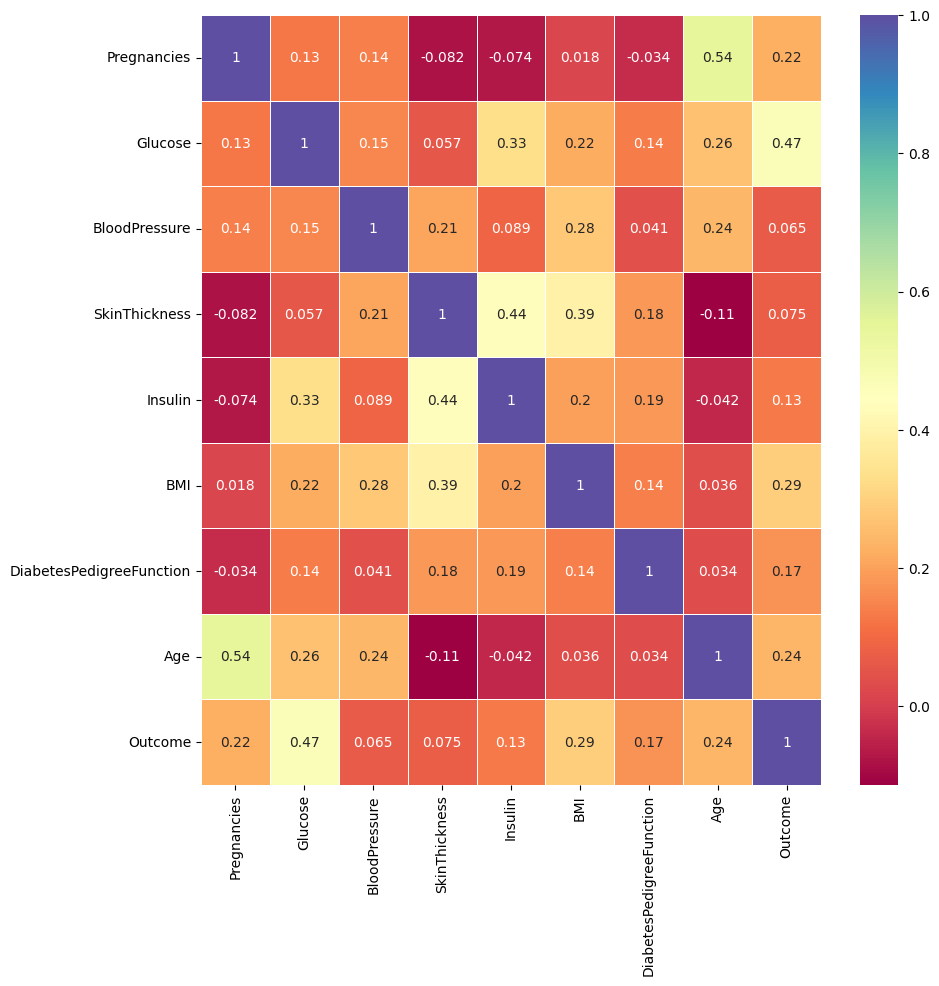

In [5]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True,cmap="Spectral",linewidth=0.5)
plt.show()

In [18]:

x = df.drop(["Outcome", "SkinThickness", "BloodPressure"], axis=1)
y = df["Outcome"]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [19]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)

In [20]:
model=tf.keras.Sequential([
    tf.keras.layers.Dense(16,activation="relu"),
    tf.keras.layers.Dense(16,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])

In [21]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
#               loss='binary_crossentropy',
#               metrics=['accuracy'])

In [22]:
history = model.fit(x_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_data=(x_test, y_test))

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6745 - loss: 0.6235 - val_accuracy: 0.6558 - val_loss: 0.6104
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6997 - loss: 0.5790 - val_accuracy: 0.7143 - val_loss: 0.5791
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6934 - loss: 0.5604 - val_accuracy: 0.7532 - val_loss: 0.5522
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7155 - loss: 0.5262 - val_accuracy: 0.7597 - val_loss: 0.5324
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7460 - loss: 0.5060 - val_accuracy: 0.7662 - val_loss: 0.5150
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7709 - loss: 0.4958 - val_accuracy: 0.7662 - val_loss: 0.5051
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7468 - loss: 0.4992 - val_accuracy: 0.7662 - val_loss: 0.4975
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7449 - loss: 0.5030 - val_accuracy: 0.7597 - val_loss

In [23]:
model.evaluate(x_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7671 - loss: 0.4946 


[0.4887514114379883, 0.7727272510528564]